# 1. Import Libraries

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

# 2. Load Dataset

In [45]:
fake_path = "../data/raw/fake.csv"
true_path = "../data/raw/true.csv"


fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

In [46]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [47]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [48]:
# Adding labels to the dataframes
fake_df["label"] = 0
true_df["label"] = 1

# Concatenating the dataframes and shuffling the rows
df = pd.concat(
    [fake_df, true_df],
    axis=0
)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1
...,...,...,...,...,...
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",1
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",1
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0


In [49]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 209


# 3. Exploratory Data Analysis

## Class Distribution

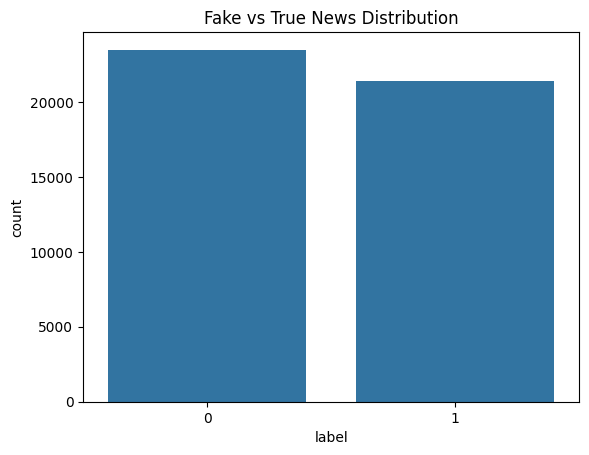

In [50]:
sns.countplot(
    data=df,
    x="label"
)

plt.title(
    "Fake vs True News Distribution"
)

plt.show()

## Text Length Analysis

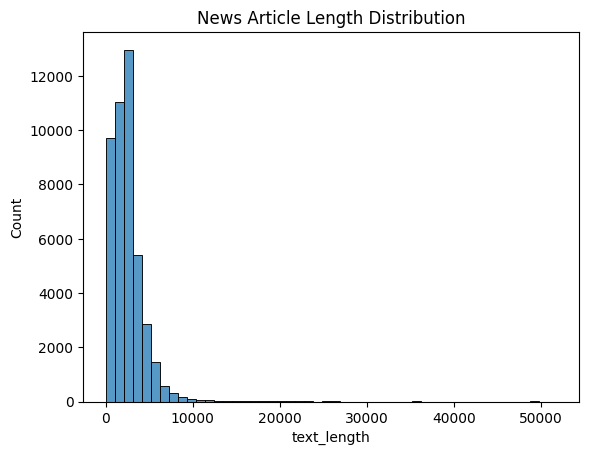

In [51]:
df["text_length"] = (
    df["text"]
    .astype(str)
    .apply(len)
)

sns.histplot(
    df["text_length"],
    bins=50
)

plt.title(
    "News Article Length Distribution"
)

plt.show()